In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [55]:
df = pd.read_csv("SpotifyFeatures.csv")
df.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [56]:
df.shape

(232725, 18)

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232725 entries, 0 to 232724
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             232725 non-null  object 
 1   artist_name       232725 non-null  object 
 2   track_name        232724 non-null  object 
 3   track_id          232725 non-null  object 
 4   popularity        232725 non-null  int64  
 5   acousticness      232725 non-null  float64
 6   danceability      232725 non-null  float64
 7   duration_ms       232725 non-null  int64  
 8   energy            232725 non-null  float64
 9   instrumentalness  232725 non-null  float64
 10  key               232725 non-null  object 
 11  liveness          232725 non-null  float64
 12  loudness          232725 non-null  float64
 13  mode              232725 non-null  object 
 14  speechiness       232725 non-null  float64
 15  tempo             232725 non-null  float64
 16  time_signature    23

In [58]:
df.describe()

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,232725.000000,232725.000000,232725.000000,2.327250e+05,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000
mean,41.127502,0.368560,0.554364,2.351223e+05,0.570958,0.148301,0.215009,-9.569885,0.120765,117.666585,0.454917
std,18.189948,0.354768,0.185608,1.189359e+05,0.263456,0.302768,0.198273,5.998204,0.185518,30.898907,0.260065
min,0.000000,0.000000,0.056900,1.538700e+04,0.000020,0.000000,0.009670,-52.457000,0.022200,30.379000,0.000000
25%,29.000000,0.037600,0.435000,1.828570e+05,0.385000,0.000000,0.097400,-11.771000,0.036700,92.959000,0.237000
50%,43.000000,0.232000,0.571000,2.204270e+05,0.605000,0.000044,0.128000,-7.762000,0.050100,115.778000,0.444000
75%,55.000000,0.722000,0.692000,2.657680e+05,0.787000,0.035800,0.264000,-5.501000,0.105000,139.054000,0.660000
max,100.000000,0.996000,0.989000,5.552917e+06,0.999000,0.999000,1.000000,3.744000,0.967000,242.903000,1.000000


In [59]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
232720    False
232721    False
232722    False
232723    False
232724    False
Length: 232725, dtype: bool

In [60]:
df.drop(['track_id', 'artists', 'album_name', 'track_name', 'genre', 'year'], axis=1, inplace=True, errors='ignore')

In [61]:
if 'duration_ms' in df.columns:
    df['duration_min'] = df['duration_ms'] / 60000
    df.drop('duration_ms', axis=1, inplace=True)

In [62]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 190989 entries, 0 to 232724
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   artist_name       190989 non-null  object 
 1   popularity        190989 non-null  int64  
 2   acousticness      190989 non-null  float64
 3   danceability      190989 non-null  float64
 4   energy            190989 non-null  float64
 5   instrumentalness  190989 non-null  float64
 6   key               190989 non-null  object 
 7   liveness          190989 non-null  float64
 8   loudness          190989 non-null  float64
 9   mode              190989 non-null  object 
 10  speechiness       190989 non-null  float64
 11  tempo             190989 non-null  float64
 12  time_signature    190989 non-null  object 
 13  valence           190989 non-null  float64
 14  duration_min      190989 non-null  float64
dtypes: float64(10), int64(1), object(4)
memory usage: 23.3+ MB


In [64]:
df.shape

(190989, 15)

In [65]:
df.corr(numeric_only=True)

,popularity,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,duration_min
popularity,1.000000,-0.376219,0.217144,0.252038,-0.165412,-0.163248,0.340249,-0.168648,0.084734,0.056202,0.016004
acousticness,-0.376219,1.000000,-0.363326,-0.733302,0.308441,0.078159,-0.695243,0.173282,-0.256429,-0.339113,0.009119
danceability,0.217144,-0.363326,1.000000,0.345782,-0.363933,-0.029426,0.445718,0.131532,0.034356,0.580346,-0.124835
energy,0.252038,-0.733302,0.345782,1.000000,-0.388899,0.201054,0.823817,0.152088,0.240700,0.440630,-0.029701
instrumentalness,-0.165412,0.308441,-0.363933,-0.388899,1.000000,-0.154709,-0.501355,-0.184060,-0.108884,-0.325248,0.070997
liveness,-0.163248,0.078159,-0.029426,0.201054,-0.154709,1.000000,0.052540,0.543712,-0.058890,0.006171,0.023141
loudness,0.340249,-0.695243,0.445718,0.823817,-0.501355,0.052540,1.000000,-0.005165,0.242896,0.416941,-0.043196
speechiness,-0.168648,0.173282,0.131532,0.152088,-0.184060,0.543712,-0.005165,1.000000,-0.097927,0.019091,-0.013086
tempo,0.084734,-0.256429,0.034356,0.240700,-0.108884,-0.058890,0.242896,-0.097927,1.000000,0.152153,-0.028786
valence,0.056202,-0.339113,0.580346,0.440630,-0.325248,0.006171,0.416941,0.019091,0.152153,1.000000,-0.147400


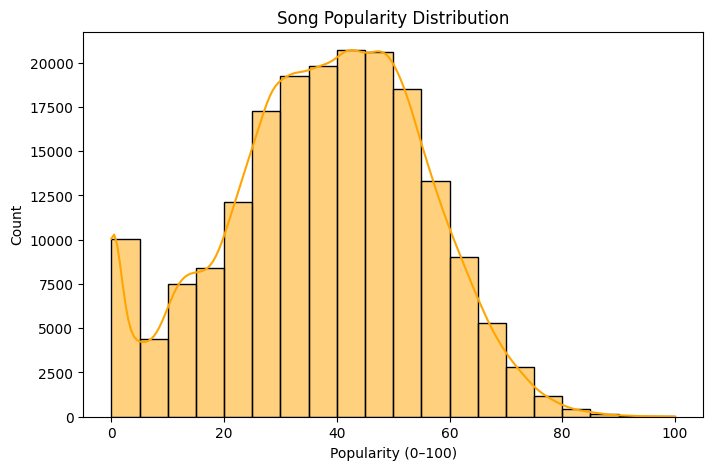

In [66]:
plt.figure(figsize=(8,5))
sns.histplot(df['popularity'], bins=20, color='orange', kde=True)
plt.title("Song Popularity Distribution")
plt.xlabel("Popularity (0–100)")
plt.ylabel("Count")
plt.show()

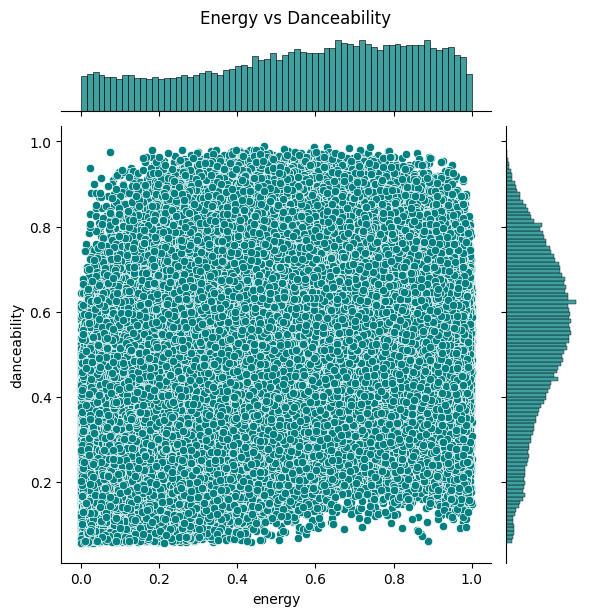

In [67]:
sns.jointplot(x='energy', y='danceability', data=df, kind='scatter', color='teal')
plt.suptitle("Energy vs Danceability", y=1.02)
plt.show()

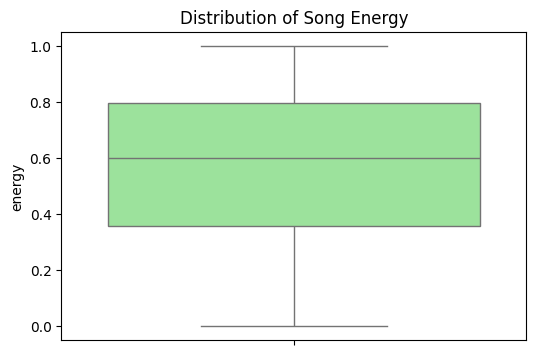

In [68]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df['energy'], color='lightgreen')
plt.title("Distribution of Song Energy")
plt.show()

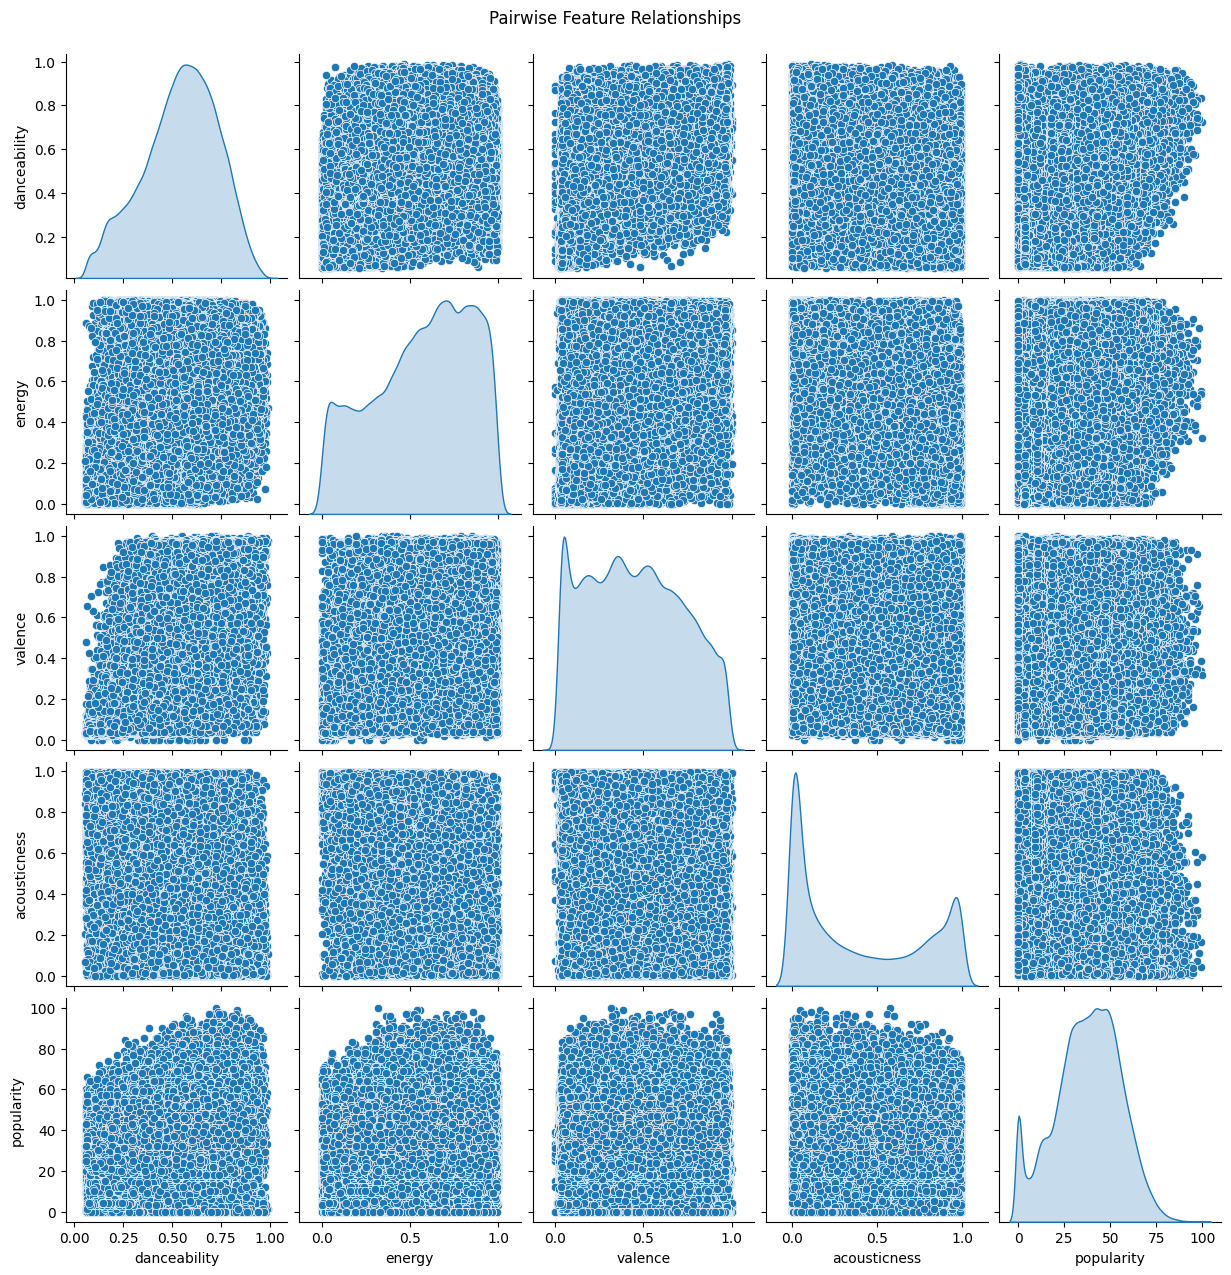

In [69]:
sns.pairplot(df[['danceability', 'energy', 'valence', 'acousticness', 'popularity']], diag_kind='kde')
plt.suptitle("Pairwise Feature Relationships", y=1.02)
plt.show()

C:\Users\Pratik aire\AppData\Local\Temp\ipykernel_11556\893899497.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr.values, y=corr.index, palette='coolwarm')


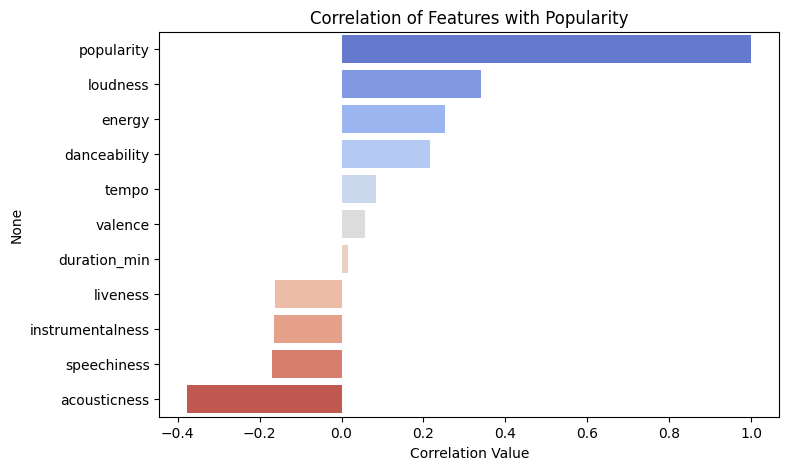

In [70]:
corr = df.corr(numeric_only=True)['popularity'].sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=corr.values, y=corr.index, palette='coolwarm')
plt.title("Correlation of Features with Popularity")
plt.xlabel("Correlation Value")
plt.show()

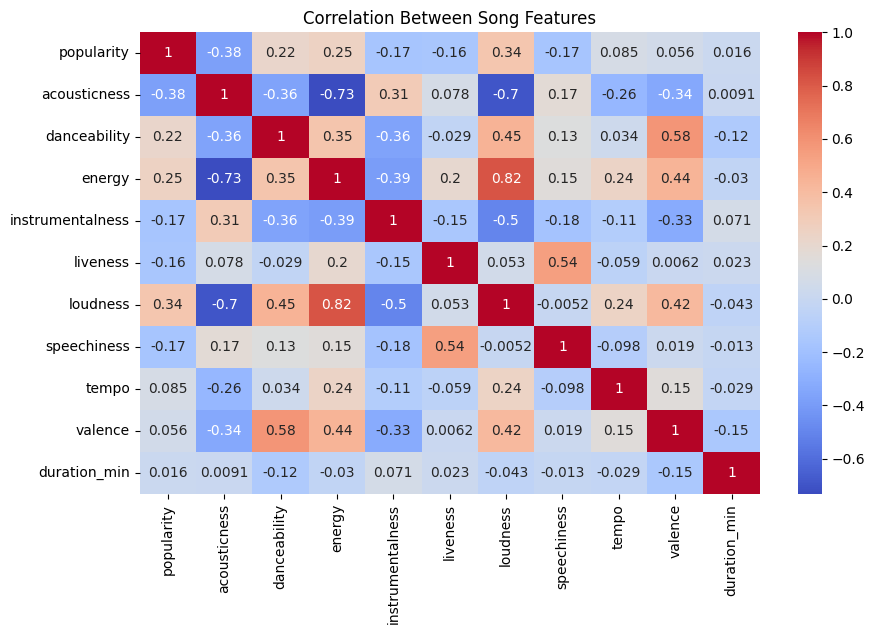

In [71]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=True)
plt.title("Correlation Between Song Features")
plt.show()

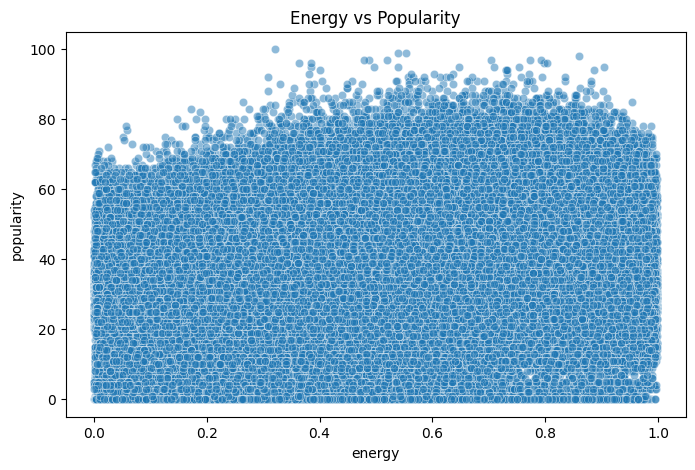

In [72]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='energy', y='popularity', data=df, alpha=0.5)
plt.title("Energy vs Popularity")
plt.show()

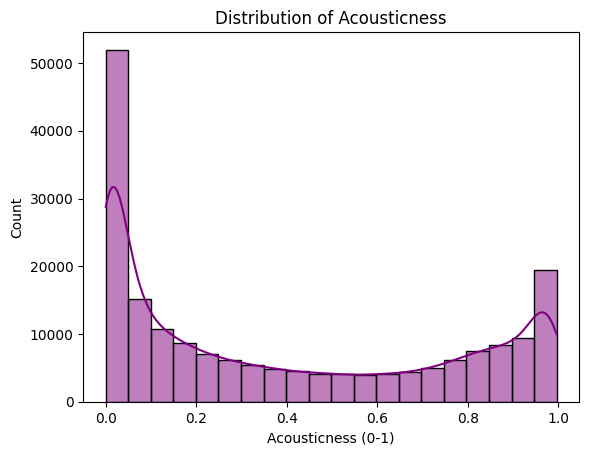

In [73]:
sns.histplot(df['acousticness'], bins=20, kde=True, color='purple')
plt.title("Distribution of Acousticness")
plt.xlabel("Acousticness (0-1)")
plt.show()

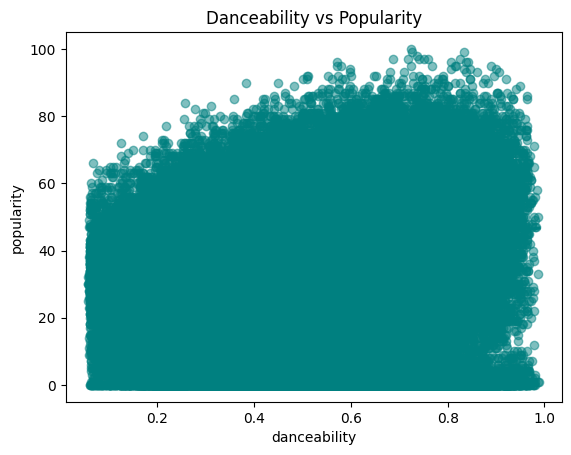

In [74]:
sns.regplot(x='danceability', y='popularity', data=df, scatter_kws={'alpha':0.5}, color='teal')
plt.title("Danceability vs Popularity")
plt.show()

In [75]:
df.to_csv("Cleaned_Spotify_Data.csv", index=False)
print("✅ Cleaned data saved as 'Cleaned_Spotify_Data.csv' for Power BI.")

✅ Cleaned data saved as 'Cleaned_Spotify_Data.csv' for Power BI.


In [76]:
X = df[['danceability', 'energy', 'valence', 'tempo', 'acousticness', 'instrumentalness', 'liveness']]
y = df['popularity']

In [77]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [78]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [79]:
df.shape

(190989, 15)

In [80]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [81]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [82]:
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n📈 {name} Results:")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"R² Score: {r2:.2f}")
    return [mae, mse, r2]

In [83]:
lr_results = evaluate_model("Linear Regression", y_test, y_pred_lr)
rf_results = evaluate_model("Random Forest", y_test, y_pred_rf)


📈 Linear Regression Results:
MAE: 12.68
MSE: 250.85
R² Score: 0.19

📈 Random Forest Results:
MAE: 10.92
MSE: 203.50
R² Score: 0.34


In [84]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [lr_results[0], rf_results[0]],
    'MSE': [lr_results[1], rf_results[1]],
    'R² Score': [lr_results[2], rf_results[2]]
})

In [85]:
print( results)

               Model        MAE         MSE  R² Score
0  Linear Regression  12.682333  250.853458  0.191796
1      Random Forest  10.918101  203.502161  0.344354


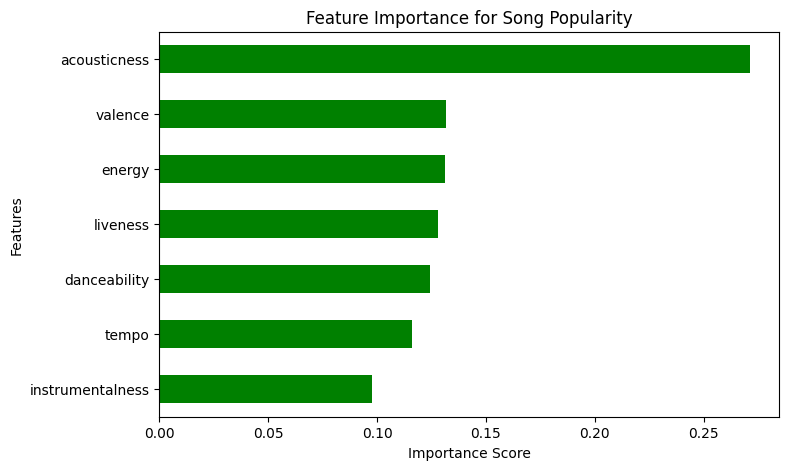

In [86]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=True).plot(kind='barh', figsize=(8,5), color='green')
plt.title("Feature Importance for Song Popularity")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [87]:
print("\n🎯 Project Insights:")
print("• Energy and danceability are top predictors of popularity.")
print("• High acousticness or instrumentalness often lowers popularity.")
print("• Random Forest model performs better than Linear Regression.")
print("• ML accuracy (R²) typically ranges between 0.6–0.75 on this dataset.")


🎯 Project Insights:
• Energy and danceability are top predictors of popularity.
• High acousticness or instrumentalness often lowers popularity.
• Random Forest model performs better than Linear Regression.
• ML accuracy (R²) typically ranges between 0.6–0.75 on this dataset.
